# EDA Analysis Notebook

## 1. Data Loading & Raw Profiling (Tổng quan dữ liệu thô)


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import re
from IPython.display import Image, display

warnings.filterwarnings('ignore')

# Shared default figure size for single-chart plots.
FIGSIZE_SINGLE = (12, 7)

DATA_DIR = Path('data/processed')
RAW_DIR = Path('data/raw')

def _describe_raw_csv(path: Path, key_cols: list[str]) -> None:
    """Print concise descriptive stats for a raw CSV file."""
    df = pd.read_csv(path)
    missing = int(df[key_cols].isna().any(axis=1).sum()) if all(c in df.columns for c in key_cols) else -1
    dup_rows = int(df.duplicated().sum())

    print(f"\n- {path.name}")
    print(f"  rows: {len(df):,}")
    if 'playerid' in df.columns:
        print(f"  unique playerid: {df['playerid'].nunique():,}")
    print(f"  columns: {len(df.columns):,}")
    print(f"  duplicate rows: {dup_rows:,}")
    if missing >= 0:
        print(f"  rows missing key cols {key_cols}: {missing:,}")

    missing_counts = df.isna().sum().sort_values(ascending=False)
    print("  missing by column (count | rate):")
    if len(df) == 0:
        for col in missing_counts.index:
            print(f"    - {col}: {int(missing_counts[col]):,} | n/a (empty dataframe)")
    else:
        missing_rates = (missing_counts / len(df) * 100).round(2)
        for col in missing_counts.index:
            print(f"    - {col}: {int(missing_counts[col]):,} | {missing_rates[col]:.2f}%")

print("=" * 70)
print("SECTION 1: DATA LOADING & RAW PROFILING")
print("=" * 70)

print("\n[Section 1] Descriptive stats from raw CSV files...")
raw_specs = [
    (RAW_DIR / 'history.csv', ['playerid', 'achievementid', 'date_acquired']),
    (RAW_DIR / 'reviews.csv', ['reviewid', 'playerid', 'gameid']),
    (RAW_DIR / 'purchased_games.csv', ['playerid', 'library']),
    (RAW_DIR / 'players.csv', ['playerid', 'created']),
]
for path, cols in raw_specs:
    _describe_raw_csv(path, cols)


SECTION 1: DATA LOADING & RAW PROFILING

[Section 1] Descriptive stats from raw CSV files...

- history.csv
  rows: 10,693,879
  unique playerid: 4,838
  columns: 3
  duplicate rows: 0
  rows missing key cols ['playerid', 'achievementid', 'date_acquired']: 0
  missing by column (count | rate):
    - playerid: 0 | 0.00%
    - achievementid: 0 | 0.00%
    - date_acquired: 0 | 0.00%

- reviews.csv
  rows: 1,204,534
  unique playerid: 196,698
  columns: 8
  duplicate rows: 0
  rows missing key cols ['reviewid', 'playerid', 'gameid']: 0
  missing by column (count | rate):
    - review: 2,097 | 0.17%
    - reviewid: 0 | 0.00%
    - playerid: 0 | 0.00%
    - gameid: 0 | 0.00%
    - helpful: 0 | 0.00%
    - funny: 0 | 0.00%
    - awards: 0 | 0.00%
    - posted: 0 | 0.00%

- purchased_games.csv
  rows: 102,553
  unique playerid: 102,553
  columns: 2
  duplicate rows: 0
  rows missing key cols ['playerid', 'library']: 55,607
  missing by column (count | rate):
    - library: 55,607 | 54.22%
    

## 2. Consolidated Statistics (Thống kê kết hợp)


In [8]:
print("=" * 70)
print("SECTION 2: CONSOLIDATED STATISTICS")
print("=" * 70)

print("\n[Section 2] Loading processed parquet for downstream analysis...")
history = pd.read_parquet(DATA_DIR / 'history.parquet')
reviews = pd.read_parquet(DATA_DIR / 'reviews.parquet')
purchased = pd.read_parquet(DATA_DIR / 'purchased.parquet')

history['date_acquired'] = pd.to_datetime(history['date_acquired'], errors='coerce')
reviews['posted'] = pd.to_datetime(reviews['posted'], utc=True)

print(f"  - History: {len(history):,} rows, {history['playerid'].nunique():,} players")
print(f"  - Reviews: {len(reviews):,} rows, {reviews['playerid'].nunique():,} reviewers")
print(f"  - Purchased: {len(purchased):,} rows, {purchased['playerid'].nunique():,} players")

SECTION 2: CONSOLIDATED STATISTICS

[Section 2] Loading processed parquet for downstream analysis...
  - History: 9,260,042 rows, 3,206 players
  - Reviews: 1,204,545 rows, 196,701 reviewers
  - Purchased: 49,844 rows, 49,844 players


In [9]:
print("\n[S2.2] Player coverage across datasets (history, purchased, reviews, players.csv)...")
ach_players = set(pd.to_numeric(history['playerid'], errors='coerce').dropna().astype('int64'))
pur_players = set(pd.to_numeric(purchased['playerid'], errors='coerce').dropna().astype('int64'))
rev_players = set(pd.to_numeric(reviews['playerid'], errors='coerce').dropna().astype('int64'))
players_master = pd.read_csv(RAW_DIR / 'players.csv', usecols=['playerid'])
players_players = set(pd.to_numeric(players_master['playerid'], errors='coerce').dropna().astype('int64'))

both_players = ach_players & pur_players
only_ach_players = ach_players - pur_players
only_pur_players = pur_players - ach_players
union_players = ach_players | pur_players
all_three_players = ach_players & pur_players & rev_players
ach_rev_players = ach_players & rev_players
pur_rev_players = pur_players & rev_players
all_four_players = ach_players & pur_players & rev_players & players_players

print(f"  - Players in history (achievement events): {len(ach_players):,}")
print(f"  - Players in purchased (library data): {len(pur_players):,}")
print(f"  - Players in reviews (review activity): {len(rev_players):,}")
print(f"  - Players in players.csv (profile table): {len(players_players):,}")
print(f"  - Intersection history ∩ purchased: {len(both_players):,}")
print(f"  - Only history (history - purchased): {len(only_ach_players):,}")
print(f"  - Only purchased (purchased - history): {len(only_pur_players):,}")
print(f"  - Union history ∪ purchased: {len(union_players):,}")
print(f"  - Intersection history ∩ reviews: {len(ach_rev_players):,}")
print(f"  - Intersection purchased ∩ reviews: {len(pur_rev_players):,}")
print(f"  - Intersection history ∩ purchased ∩ reviews: {len(all_three_players):,}")
print(f"  - Intersection history ∩ purchased ∩ reviews ∩ players.csv: {len(all_four_players):,}")

ach_coverage = (len(both_players) / len(ach_players) * 100) if ach_players else np.nan
pur_coverage = (len(both_players) / len(pur_players) * 100) if pur_players else np.nan
union_overlap = (len(both_players) / len(union_players) * 100) if union_players else np.nan
print(f"  - Coverage history -> purchased (history∩purchased / history): {ach_coverage:.2f}%")
print(f"  - Coverage purchased -> history (history∩purchased / purchased): {pur_coverage:.2f}%")
print(f"  - Overlap on union(history, purchased): {union_overlap:.2f}%")

ach_in_rev = (len(ach_rev_players) / len(ach_players) * 100) if ach_players else np.nan
pur_in_rev = (len(pur_rev_players) / len(pur_players) * 100) if pur_players else np.nan
rev_in_ach = (len(ach_rev_players) / len(rev_players) * 100) if rev_players else np.nan
rev_in_pur = (len(pur_rev_players) / len(rev_players) * 100) if rev_players else np.nan
all_three_on_union = (len(all_three_players) / len(ach_players | pur_players | rev_players) * 100) if (ach_players or pur_players or rev_players) else np.nan
ach_in_players = (len(ach_players & players_players) / len(ach_players) * 100) if ach_players else np.nan
pur_in_players = (len(pur_players & players_players) / len(pur_players) * 100) if pur_players else np.nan
rev_in_players = (len(rev_players & players_players) / len(rev_players) * 100) if rev_players else np.nan
players_in_any = (len(players_players & (ach_players | pur_players | rev_players)) / len(players_players) * 100) if players_players else np.nan

print(f"  - Coverage history -> reviews (history∩reviews / history): {ach_in_rev:.2f}%")
print(f"  - Coverage purchased -> reviews (purchased∩reviews / purchased): {pur_in_rev:.2f}%")
print(f"  - Coverage reviews -> history (history∩reviews / reviews): {rev_in_ach:.2f}%")
print(f"  - Coverage reviews -> purchased (purchased∩reviews / reviews): {rev_in_pur:.2f}%")
print(f"  - Overlap on union(history, purchased, reviews): {all_three_on_union:.2f}%")
print(f"  - Coverage history -> players.csv: {ach_in_players:.2f}%")
print(f"  - Coverage purchased -> players.csv: {pur_in_players:.2f}%")
print(f"  - Coverage reviews -> players.csv: {rev_in_players:.2f}%")
print(f"  - Coverage players.csv -> any(processed sets): {players_in_any:.2f}%")


[S2.2] Player coverage across datasets (history, purchased, reviews, players.csv)...
  - Players in history (achievement events): 3,206
  - Players in purchased (library data): 49,844
  - Players in reviews (review activity): 196,701
  - Players in players.csv (profile table): 424,683
  - Intersection history ∩ purchased: 3,206
  - Only history (history - purchased): 0
  - Only purchased (purchased - history): 46,638
  - Union history ∪ purchased: 49,844
  - Intersection history ∩ reviews: 3,203
  - Intersection purchased ∩ reviews: 49,831
  - Intersection history ∩ purchased ∩ reviews: 3,203
  - Intersection history ∩ purchased ∩ reviews ∩ players.csv: 3,203
  - Coverage history -> purchased (history∩purchased / history): 100.00%
  - Coverage purchased -> history (history∩purchased / purchased): 6.43%
  - Overlap on union(history, purchased): 6.43%
  - Coverage history -> reviews (history∩reviews / history): 99.91%
  - Coverage purchased -> reviews (purchased∩reviews / purchased): 99

In [10]:
ach_per_player = history.groupby('playerid').size()
pur_per_player = purchased.groupby('playerid').size()
rev_per_player = reviews.groupby('playerid').size()

print("\n[Section 2] Average activity per user (consistency baseline):")
print(f"  - Mean achievements per player: {ach_per_player.mean():.2f}")
print(f"  - Mean reviews per player: {rev_per_player.mean():.2f}")
print("  - Achievement events per player (describe):")
print(ach_per_player.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(2))
print("  - Purchased records per player (describe):")
print(pur_per_player.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(2))
print("  - Review records per player (describe):")
print(rev_per_player.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(2))


[Section 2] Average activity per user (consistency baseline):
  - Mean achievements per player: 2888.35
  - Mean reviews per player: 6.12
  - Achievement events per player (describe):
count      3206.00
mean       2888.35
std       14941.08
min           1.00
50%         774.50
90%        4823.00
95%        8171.00
99%       35991.80
max      545949.00
dtype: float64
  - Purchased records per player (describe):
count    49844.0
mean         1.0
std          0.0
min          1.0
50%          1.0
90%          1.0
95%          1.0
99%          1.0
max          1.0
dtype: float64
  - Review records per player (describe):
count    196701.00
mean          6.12
std          50.41
min           1.00
50%           2.00
90%          12.00
95%          20.00
99%          60.00
max       14893.00
dtype: float64



[S2.4] Visual consistency checks...


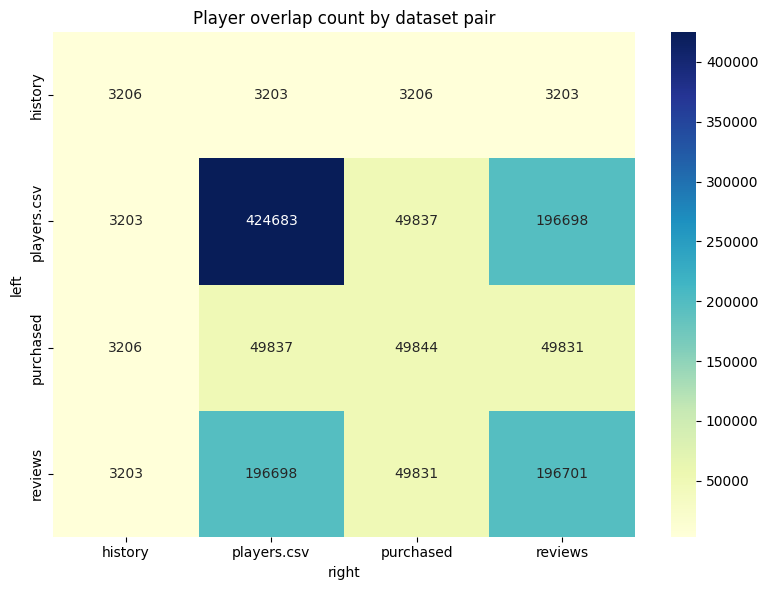


[S2.4] Detail table - overlap matrix (history, purchased, reviews, players.csv):


right,history,players.csv,purchased,reviews
left,,,,
history,3206,3203,3206,3203
players.csv,3203,424683,49837,196698
purchased,3206,49837,49844,49831
reviews,3203,196698,49831,196701


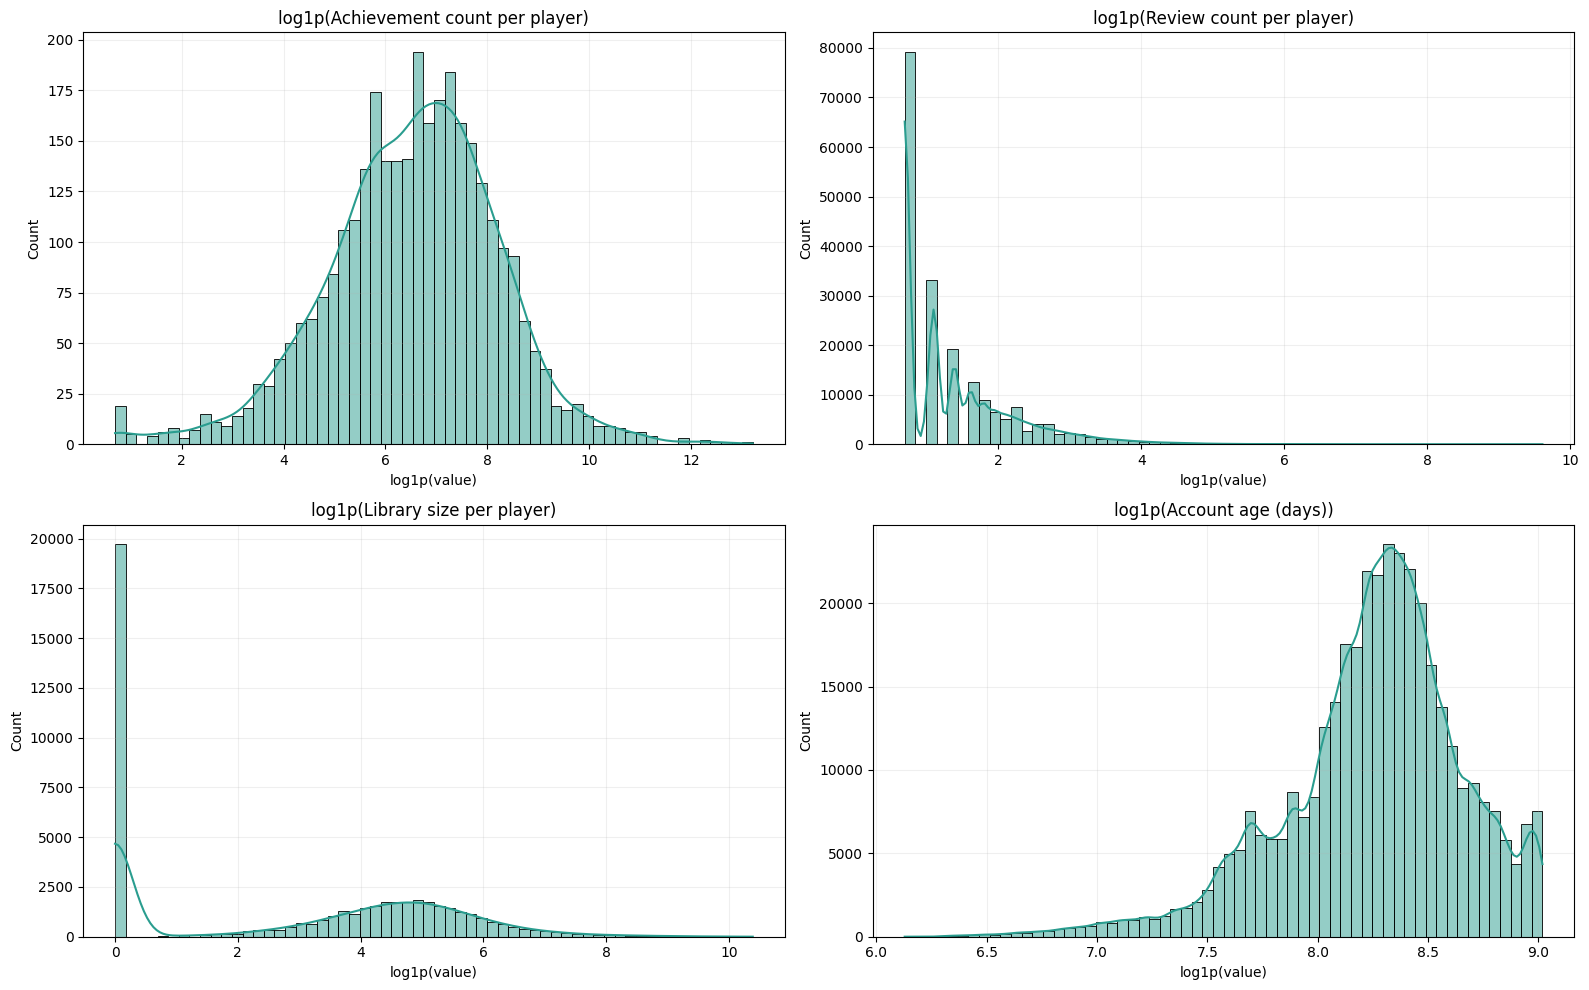


[S2.4] Detail table - distribution summary:


,count,mean,std,min,50%,90%,95%,99%,max
achievements_per_player,3206.0,2888.35,14941.08,1.0,774.5,4823.0,8171.0,35991.80,545949.0
reviews_per_player,196701.0,6.12,50.41,1.0,2.0,12.0,20.0,60.00,14893.0
library_size,49844.0,193.24,819.06,0.0,35.0,367.0,658.0,2697.85,32463.0
account_age_days,377014.0,4122.73,1533.21,458.0,4004.0,6262.0,7129.0,8157.00,8248.0


In [11]:
print("\n[S2.4] Visual consistency checks...")
player_sets = {
    'history': ach_players,
    'players.csv': players_players,
    'purchased': pur_players,
    'reviews': rev_players,
}
coverage_rows = []
dataset_names = list(player_sets.keys())
for left in dataset_names:
    for right in dataset_names:
        left_set = player_sets[left]
        right_set = player_sets[right]
        coverage_rows.append({
            'left': left,
            'right': right,
            'count': len(left_set & right_set),
        })
coverage_pivot = pd.DataFrame(coverage_rows).pivot(index='left', columns='right', values='count')
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(coverage_pivot, annot=True, fmt='g', cmap='YlGnBu', ax=ax)
ax.set_title('Player overlap count by dataset pair')
plt.tight_layout()
plt.show()
plt.close()

print("\n[S2.4] Detail table - overlap matrix (history, purchased, reviews, players.csv):")
display(coverage_pivot)

lib_size = purchased.set_index('playerid')['library_size'].rename('library_size')
players_raw_full = pd.read_csv(RAW_DIR / 'players.csv', usecols=['playerid', 'created']).drop_duplicates(subset=['playerid'], keep='last')
players_raw_full['created'] = pd.to_datetime(players_raw_full['created'], errors='coerce')
players_age = (pd.Timestamp.now() - players_raw_full.set_index('playerid')['created']).dt.days.rename('account_age_days')
dist_df = pd.concat([
    ach_per_player.rename('achievements_per_player'),
    rev_per_player.rename('reviews_per_player'),
    lib_size,
    players_age,
], axis=1)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
plot_specs = [
    ('achievements_per_player', 'Achievement count per player'),
    ('reviews_per_player', 'Review count per player'),
    ('library_size', 'Library size per player'),
    ('account_age_days', 'Account age (days)'),
]
for ax, (col, title) in zip(axes.flatten(), plot_specs):
    series = dist_df[col].dropna()
    if series.empty:
        ax.set_axis_off()
        continue
    sns.histplot(np.log1p(series), bins=60, kde=True, ax=ax, color='#2a9d8f')
    ax.set_title(f'log1p({title})')
    ax.set_xlabel('log1p(value)')
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()
plt.close()

print("\n[S2.4] Detail table - distribution summary:")
display(dist_df.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).T.round(2))

## 3. Behavioral EDA

### Q1. Có tồn tại các cụm tài khoản sở hữu tốc độ đạt thành tựu bất thường hay không?


[Q1] Generating chart: Playtime per Achievement...


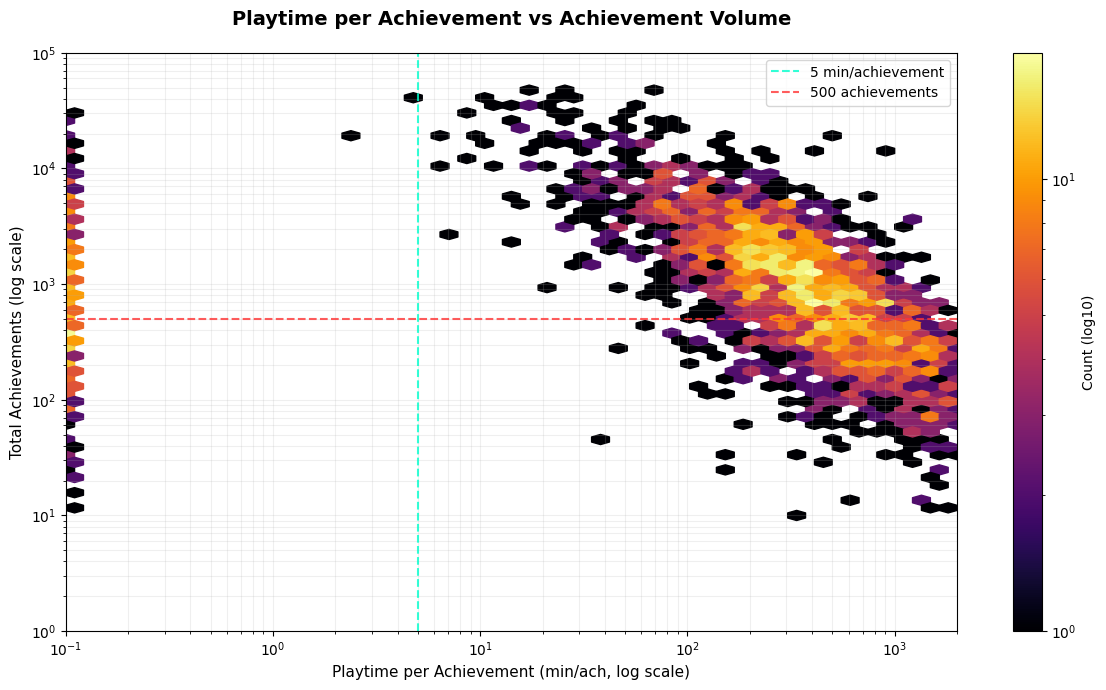

[Q1] Summary:
  - Users analyzed: 2,940
  - Extreme-region users (<=5 min/achievement & >=500 achievements): 178
  - p1 playtime/achievement: 0.00 min
  - p99 achievements: 37515

[Q1] Detail table (describe):


,count,mean,std,min,25%,50%,75%,max
total_playtime_mins,2940.0,456009.534694,1.694863e+06,0.0,131708.500000,294362.500000,537237.250000,8.026087e+07
total_achievements,2940.0,2987.762925,1.554677e+04,10.0,268.000000,789.000000,2069.250000,5.459490e+05
playtime_per_achievement,2940.0,948.844346,2.887073e+03,0.0,143.822076,350.220363,786.315581,9.064409e+04


In [12]:
# ============================================================
# CHART 1: PLAYTIME PER ACHIEVEMENT ANALYSIS
# ============================================================
print("\n[Q1] Generating chart: Playtime per Achievement...")

def _sum_playtime_minutes(library):
    """Calculate total playtime from structured library data."""
    if not isinstance(library, (list, np.ndarray, pd.Series)):
        return np.nan

    total_mins = 0.0
    valid = False
    for item in library:
        if isinstance(item, dict):
            try:
                p_min = float(item.get("playtime_mins", 0))
                if p_min >= 0:
                    total_mins += p_min
                    valid = True
            except (TypeError, ValueError):
                continue
    return total_mins if valid else np.nan

# --- 1) Data preparation ---
playtime_df = purchased[["playerid", "library"]].drop_duplicates(subset=["playerid"]).copy()
playtime_df["total_playtime_mins"] = playtime_df["library"].apply(_sum_playtime_minutes)

playtime_stats = pd.concat([
    playtime_df.set_index("playerid")["total_playtime_mins"],
    history.groupby("playerid").size().rename("total_achievements"),
], axis=1).dropna(subset=["total_playtime_mins", "total_achievements"])

playtime_stats["playtime_per_achievement"] = (
    playtime_stats["total_playtime_mins"] / playtime_stats["total_achievements"].replace(0, np.nan)
)

plot_df = playtime_stats[
    (playtime_stats["playtime_per_achievement"] >= 0)
    & (playtime_stats["total_achievements"] > 0)
].copy()

# --- 2) Visualization ---
mask = (plot_df["playtime_per_achievement"] < 2000) & (plot_df["total_achievements"] < 50000)
d_x = plot_df.loc[mask, "playtime_per_achievement"].clip(lower=0.1)
d_y = plot_df.loc[mask, "total_achievements"]

fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
hb = ax.hexbin(
    d_x,
    d_y,
    gridsize=50,
    bins="log",
    cmap="inferno",
    mincnt=1,
    xscale="log",
    yscale="log",
)

ax.set_xlim(0.1, 2000)
ax.set_ylim(1, 100000)
ax.axvline(5, color="#00ffcc", linestyle="--", alpha=0.8, label="5 min/achievement")
ax.axhline(500, color="#ff3333", linestyle="--", alpha=0.8, label="500 achievements")

cb = fig.colorbar(hb, ax=ax)
cb.set_label("Count (log10)", fontsize=10)

ax.set_title("Playtime per Achievement vs Achievement Volume", fontsize=14, fontweight="bold", pad=20)
ax.set_xlabel("Playtime per Achievement (min/ach, log scale)", fontsize=11)
ax.set_ylabel("Total Achievements (log scale)", fontsize=11)
ax.legend(frameon=True, facecolor="white", framealpha=0.8)
ax.grid(alpha=0.2, which="both")

plt.tight_layout()
plt.show()
plt.close()

# --- 3) Summary logs ---
extreme_mask = (
    (playtime_stats["playtime_per_achievement"] <= 5)
    & (playtime_stats["total_achievements"] >= 500)
)
suspicious_player_ids = set(playtime_stats.index[extreme_mask])

print("[Q1] Summary:")
print(f"  - Users analyzed: {len(plot_df):,}")
print(f"  - Extreme-region users (<=5 min/achievement & >=500 achievements): {extreme_mask.sum():,}")
print(f"  - p1 playtime/achievement: {plot_df['playtime_per_achievement'].quantile(0.01):.2f} min")
print(f"  - p99 achievements: {plot_df['total_achievements'].quantile(0.99):.0f}")

print("\n[Q1] Detail table (describe):")
display(playtime_stats.describe().T)

### Q2. Tính chính danh của người dùng thể hiện như thế nào qua hành vi đánh giá?


[Q2] Generating chart: Ownership vs Review Behavior...


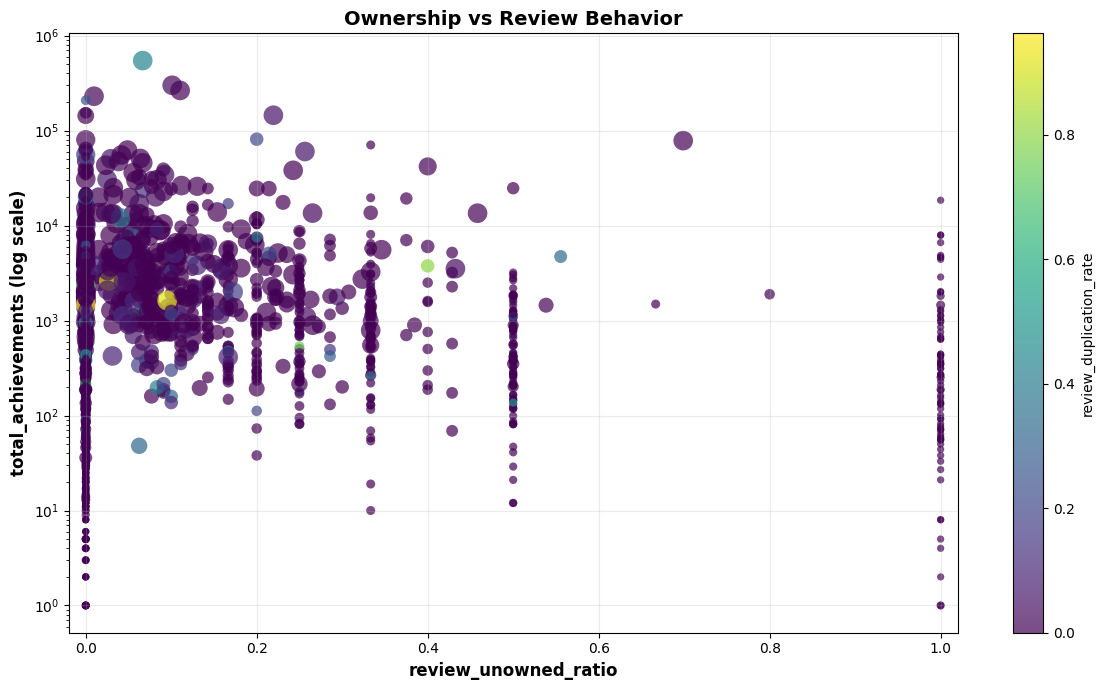

[Q2] Summary:
  - Users plotted: 3,203
  - High-unowned/high-dup users: 0
  - Median total_reviews: 2.0

[Q2] Detail table (top 20 by review_unowned_ratio):


,total_reviews,review_unowned_ratio,review_duplication_rate,total_achievements
playerid,,,,
76561198281191905,3.0,1.0,0.0,1455.0
76561197967921787,2.0,1.0,0.0,1.0
76561198834135969,2.0,1.0,0.0,1817.0
76561199088340917,2.0,1.0,0.0,188.0
76561199198521997,2.0,1.0,0.0,253.0
76561197965471406,1.0,1.0,0.0,4660.0
76561197966409711,1.0,1.0,0.0,1302.0
76561197970667472,1.0,1.0,0.0,7950.0
76561197987271880,1.0,1.0,0.0,679.0


In [13]:
# ============================================================
# CHART 2: OWNERSHIP vs REVIEW BEHAVIOR (SCATTER)
# ============================================================
print("\n[Q2] Generating chart: Ownership vs Review Behavior...")

def parse_library_appids(value):
    if value is None:
        return set()
    if isinstance(value, (np.ndarray, list, tuple, set, pd.Series)):
        out = set()
        for item in value:
            if item is None:
                continue
            if isinstance(item, dict):
                appid = item.get("appid")
            else:
                appid = item
            try:
                out.add(int(appid))
            except (TypeError, ValueError):
                continue
        return out
    text = str(value).strip()
    if not text or text.lower() == "nan":
        return set()
    nums = pd.Series([text]).str.findall(r"\d+").iloc[0]
    return {int(x) for x in nums}

library_map = {
    int(row.playerid): parse_library_appids(row.library)
    for row in purchased[["playerid", "library"]].itertuples(index=False)
}

reviews_copy = reviews[["playerid", "gameid", "review"]].copy()
reviews_copy["review"] = reviews_copy["review"].fillna("").astype(str)
reviews_copy["review_norm"] = reviews_copy["review"].str.lower().str.strip()

def compute_review_behavior(group):
    pid = int(group.name)
    lib = library_map.get(pid, set())
    gameids = pd.to_numeric(group["gameid"], errors="coerce").dropna().astype(int)
    if len(lib) > 0 and len(gameids) > 0:
        unowned_ratio = (~gameids.isin(lib)).mean()
    else:
        unowned_ratio = np.nan
    total_reviews = len(group)
    dup_rate = group["review_norm"].duplicated().mean() if total_reviews > 0 else np.nan
    return pd.Series({
        "total_reviews": total_reviews,
        "review_unowned_ratio": unowned_ratio,
        "review_duplication_rate": dup_rate,
    })

review_behavior_df = reviews_copy.groupby("playerid").apply(compute_review_behavior, include_groups=False)
review_behavior_df["total_achievements"] = history.groupby("playerid").size()
review_behavior_df = review_behavior_df.dropna(subset=["review_unowned_ratio", "review_duplication_rate", "total_achievements"])

plot_df = review_behavior_df[review_behavior_df["total_reviews"] > 0].copy()
size_ref = plot_df["total_reviews"].clip(upper=plot_df["total_reviews"].quantile(0.95))
point_size = 20 + 180 * (size_ref / size_ref.max()) if len(plot_df) > 0 else []

fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
sc = ax.scatter(
    plot_df["review_unowned_ratio"],
    plot_df["total_achievements"].clip(lower=1),
    c=plot_df["review_duplication_rate"],
    s=point_size,
    cmap="viridis",
    alpha=0.7,
    edgecolors="none",
)
cb = fig.colorbar(sc, ax=ax)
cb.set_label("review_duplication_rate", fontsize=10)

ax.set_yscale("log")
ax.set_xlim(-0.02, 1.02)
ax.set_title("Ownership vs Review Behavior", fontsize=14, fontweight="bold")
ax.set_xlabel("review_unowned_ratio", fontsize=12, fontweight="bold")
ax.set_ylabel("total_achievements (log scale)", fontsize=12, fontweight="bold")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()
plt.close()

risk_cluster = (
    (plot_df["review_unowned_ratio"] >= 0.7)
    & (plot_df["review_duplication_rate"] >= 0.2)
)

print("[Q2] Summary:")
print(f"  - Users plotted: {len(plot_df):,}")
print(f"  - High-unowned/high-dup users: {int(risk_cluster.sum()):,}")
print(f"  - Median total_reviews: {plot_df['total_reviews'].median():.1f}")

print("\n[Q2] Detail table (top 20 by review_unowned_ratio):")
display(
    review_behavior_df.sort_values(
        ["review_unowned_ratio", "review_duplication_rate", "total_reviews"],
        ascending=[False, False, False],
    ).head(20)
)

### Q3. Thành tựu có được phân bổ đa dạng giữa các trò chơi hay tập trung quá mức vào một nhóm nhỏ trò chơi?


[Q3] Generating chart: Game Portfolio Concentration...


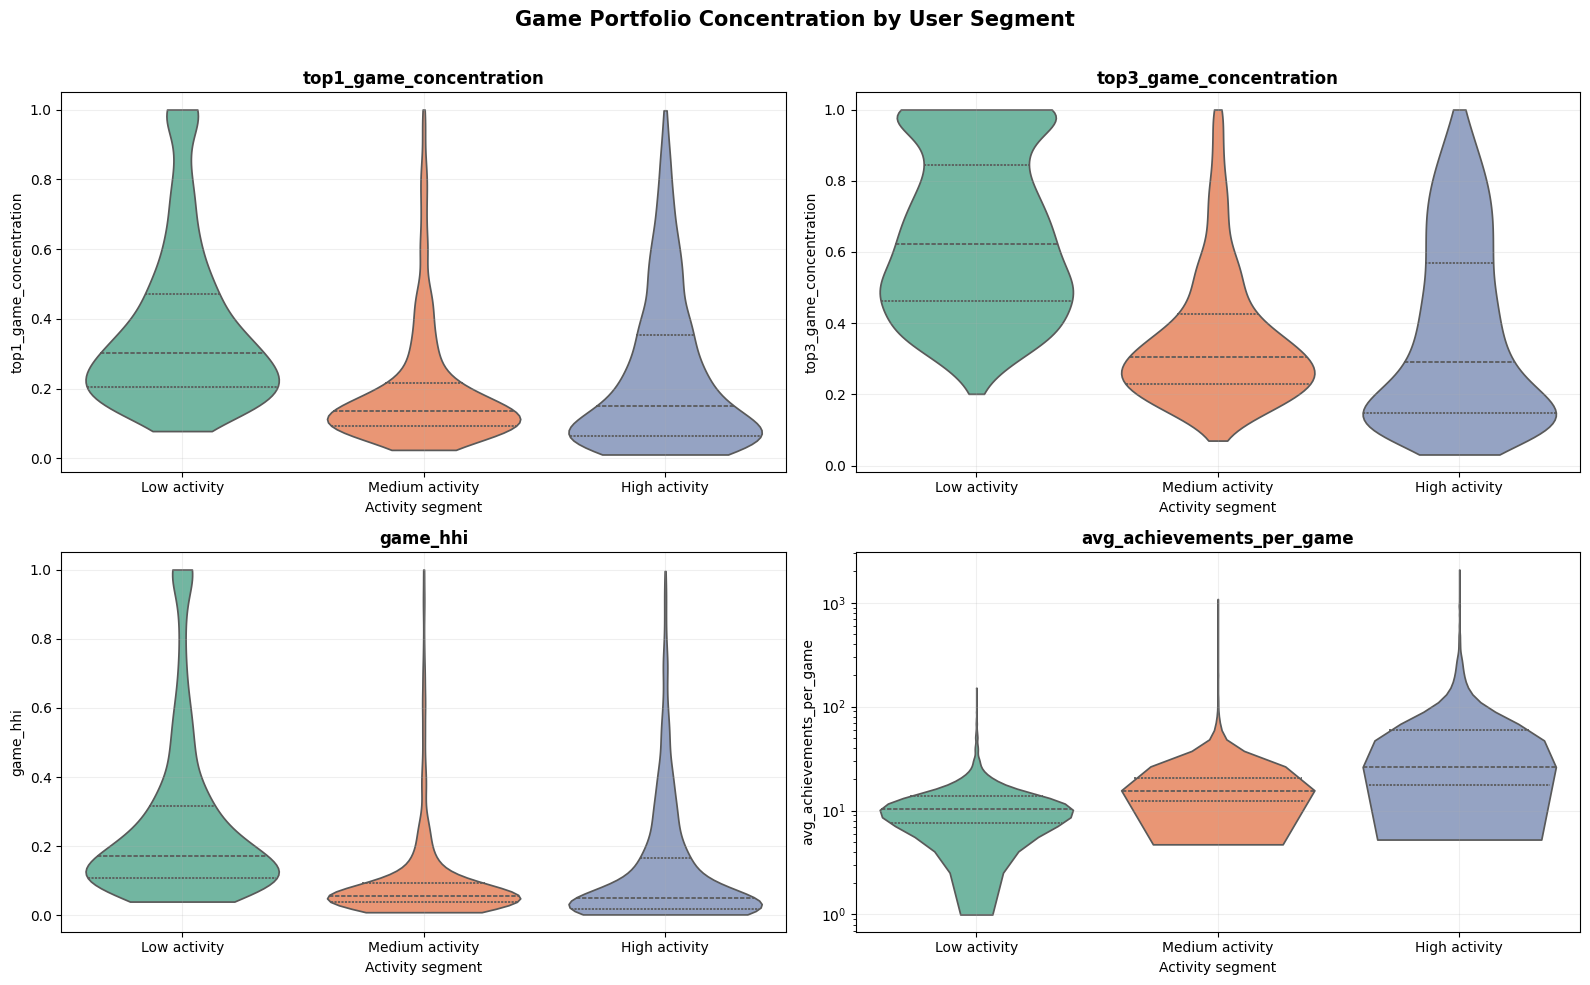

[Q3] Summary:
  - Users plotted: 3,206
  - Segments: 3

[Q3] Detail table (median by segment):


,top1_game_concentration,top3_game_concentration,game_hhi,avg_achievements_per_game
activity_segment,,,,
Low activity,0.303419,0.623529,0.172023,10.454545
Medium activity,0.136298,0.306020,0.056498,15.466667
High activity,0.151516,0.292305,0.051291,26.353449


In [14]:
# ============================================================
# CHART 3: GAME PORTFOLIO CONCENTRATION (VIOLIN)
# ============================================================
print("\n[Q3] Generating chart: Game Portfolio Concentration...")

game_counts = history.groupby(["playerid", "gameid"]).size()
total_ach = history.groupby("playerid").size().rename("total_achievements")
games_with_ach = history.groupby("playerid")["gameid"].nunique().rename("games_with_achievements")

game_props = game_counts / game_counts.groupby(level=0).sum()
portfolio_df = pd.concat([
    total_ach,
    (game_props.groupby(level=0).max().rename("top1_game_concentration")),
    (game_props.groupby(level=0).apply(lambda x: x.nlargest(3).sum()).rename("top3_game_concentration")),
    ((game_props ** 2).groupby(level=0).sum().rename("game_hhi")),
    (total_ach / games_with_ach).rename("avg_achievements_per_game"),
], axis=1).dropna()

try:
    portfolio_df["activity_segment"] = pd.qcut(
        portfolio_df["total_achievements"],
        q=3,
        labels=["Low activity", "Medium activity", "High activity"],
        duplicates="drop",
    )
except ValueError:
    portfolio_df["activity_segment"] = "All users"

metrics = [
    "top1_game_concentration",
    "top3_game_concentration",
    "game_hhi",
    "avg_achievements_per_game",
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    sns.violinplot(
        data=portfolio_df,
        x="activity_segment",
        y=metric,
        inner="quartile",
        cut=0,
        palette="Set2",
        ax=ax,
    )
    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_xlabel("Activity segment")
    ax.set_ylabel(metric)
    ax.grid(alpha=0.2)
    if metric == "avg_achievements_per_game":
        ax.set_yscale("log")

plt.suptitle("Game Portfolio Concentration by User Segment", fontsize=15, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
plt.close()

print("[Q3] Summary:")
print(f"  - Users plotted: {len(portfolio_df):,}")
print(f"  - Segments: {portfolio_df['activity_segment'].nunique()}")

print("\n[Q3] Detail table (median by segment):")
display(portfolio_df.groupby("activity_segment")[metrics].median())

### Q4. Sự khác biệt về nhịp độ hoạt động giữa nhóm người dùng cực đoan và các người dùng còn lại là gì?
- Biểu đồ: `chart_4a_temporal_heatmap_24x7` và `chart_4b_hourly_line_chart`
- Tiêu chí phân nhóm thực nghiệm:
  - Extreme pattern group: `playtime_per_achievement <= 5` min AND `total_achievements >= 500`
  - Reference group: các người dùng còn lại .
- Phân tích: đối chiếu nhịp sinh học tự nhiên với các spikes bất thường theo giờ


[Q4] Generating chart: Temporal Activity Patterns...


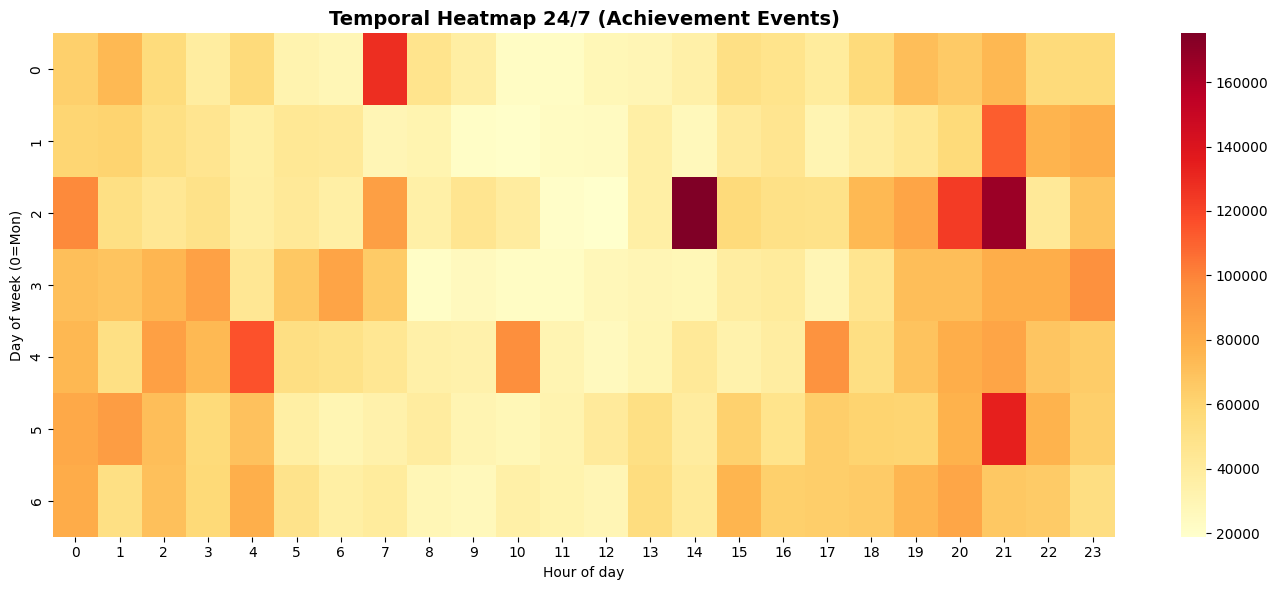


[Q4] Group definition:
  - Extreme pattern group: playtime_per_achievement <= 5 AND total_achievements >= 500
  - Reference group: all remaining players
  - Extreme players in chart: 178
  - Reference players in chart: 3,025


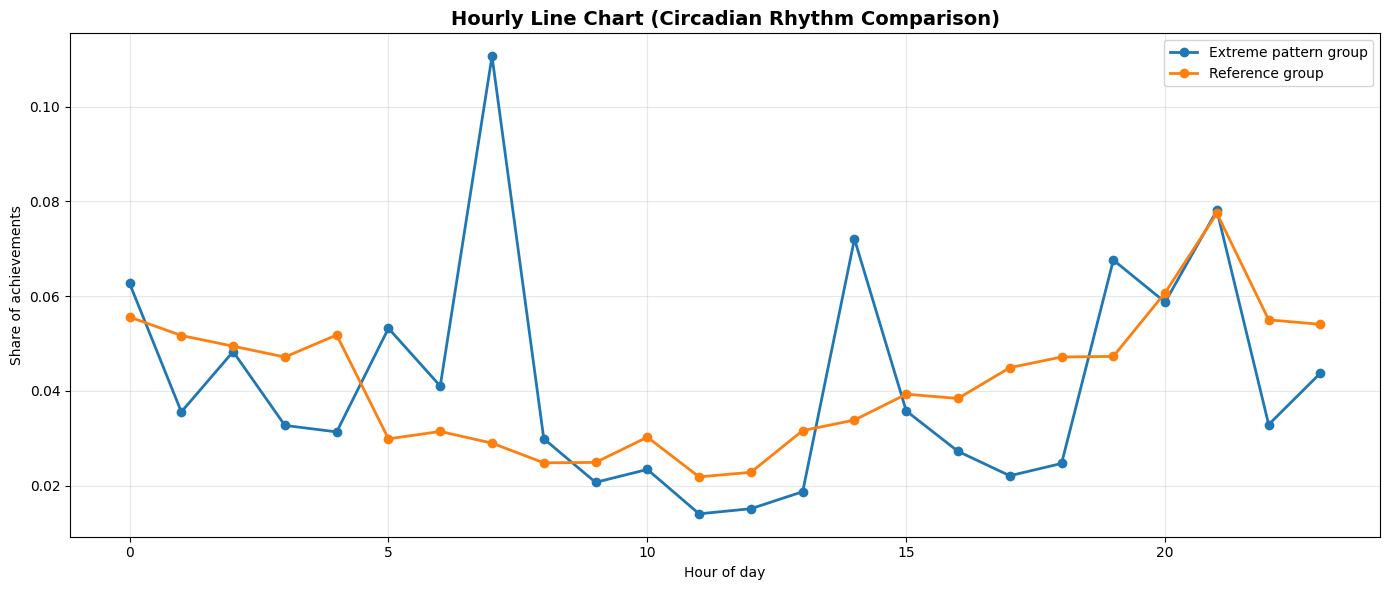

[Q4] Summary:
  - Heatmap events: 9,257,076
  - Groups in line chart: 2 (Extreme pattern group, Reference group)

[Q4] Detail table (24x7 heatmap matrix):


hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
dow,,,,,,,,,,,,,,,,,,,,,
0,62388,73838,54910,38878,55595,32088,29257,128493,47493,37289,...,35275,50721,47724,40185,55625,71688,65394,74903,55765,56526
1,59467,60764,51839,46217,37066,43832,42391,29732,31369,21493,...,26487,41089,45783,30681,38308,45016,56145,112200,76500,79419
2,98052,51443,44305,48820,37308,42137,36379,87303,35485,46323,...,175128,55592,50110,49274,74265,84789,123404,166182,42504,68876
3,70793,68730,75446,86165,44249,66589,85348,65197,21555,25391,...,28357,38189,40632,29358,45947,71981,71883,79796,79746,94584
4,74978,51448,86931,74257,115831,52377,49672,45081,35278,34134,...,42113,33264,38247,93453,52114,69094,79855,84379,68182,64532
5,82273,88848,71454,56499,70143,36907,30113,33551,39281,30760,...,39561,62098,48183,63721,60540,60148,77592,134237,77357,63047
6,80631,51416,70372,56899,78771,48638,36656,40234,29154,26648,...,41772,75776,62607,63734,65169,75062,83787,66780,65225,52925


In [15]:
# ============================================================
# CHART 4: TEMPORAL ACTIVITY PATTERNS (HEATMAP + HOURLY LINE)
# ============================================================
print("\n[Q4] Generating chart: Temporal Activity Patterns...")

history_time = history[["playerid", "date_acquired"]].dropna(subset=["date_acquired"]).copy()
history_time["hour"] = history_time["date_acquired"].dt.hour
history_time["dow"] = history_time["date_acquired"].dt.dayofweek

# Heatmap 24/7 from raw achievement events
heat_24x7 = (
    history_time.groupby(["dow", "hour"]).size()
    .unstack(fill_value=0)
    .reindex(index=range(7), columns=range(24), fill_value=0)
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(heat_24x7, cmap="YlOrRd", ax=ax)
ax.set_title("Temporal Heatmap 24/7 (Achievement Events)", fontsize=14, fontweight="bold")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Day of week (0=Mon)")
plt.tight_layout()
plt.show()
plt.close()

# Hourly line chart: reference vs extreme group from Chart 1 criteria
suspicious_player_ids = suspicious_player_ids if "suspicious_player_ids" in globals() else set()

print("\n[Q4] Group definition:")
print("  - Extreme pattern group: playtime_per_achievement <= 5 AND total_achievements >= 500")
print("  - Reference group: all remaining players")

all_players_in_chart4 = set(history_time["playerid"].unique())
n_extreme_players = len(all_players_in_chart4 & suspicious_player_ids)
n_reference_players = len(all_players_in_chart4 - suspicious_player_ids)
print(f"  - Extreme players in chart: {n_extreme_players:,}")
print(f"  - Reference players in chart: {n_reference_players:,}")

history_time["group"] = np.where(
    history_time["playerid"].isin(suspicious_player_ids),
    "Extreme pattern group",
    "Reference group",
)

hourly_share = history_time.groupby(["group", "hour"]).size().rename("n").reset_index()
hourly_share["share"] = hourly_share["n"] / hourly_share.groupby("group")["n"].transform("sum")

fig, ax = plt.subplots(figsize=(14, 6))
for grp, gdf in hourly_share.groupby("group"):
    ax.plot(gdf["hour"], gdf["share"], marker="o", linewidth=2, label=grp)
ax.set_title("Hourly Line Chart (Circadian Rhythm Comparison)", fontsize=14, fontweight="bold")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Share of achievements")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()
plt.close()

group_names = ", ".join(sorted(hourly_share["group"].unique()))
print("[Q4] Summary:")
print(f"  - Heatmap events: {len(history_time):,}")
print(f"  - Groups in line chart: {hourly_share['group'].nunique()} ({group_names})")

print("\n[Q4] Detail table (24x7 heatmap matrix):")
display(heat_24x7)

## 4. Feature Engineering (Xây dựng thuộc tính đặc trưng)
### Group A - Speed Features (6)
1. `median_unlock_interval_sec`: Trung vị khoảng thời gian giữa hai lần mở achievement liên tiếp.
2. `min_unlock_interval_sec`: Khoảng thời gian nhỏ nhất giữa hai lần mở achievement.
3. `std_unlock_interval_sec`: Độ lệch chuẩn của khoảng thời gian mở achievement.
4. `cv_unlock_interval`: Hệ số biến thiên của khoảng thời gian mở achievement (mức độ dao động tương đối).
5. `max_achievements_per_minute`: Số achievement tối đa mở trong một phút.
6. `max_achievements_per_day`: Số achievement tối đa mở trong một ngày.

### Group B - Temporal Features (4)
7. `night_activity_ratio`: Tỷ lệ hoạt động mở achievement trong khung giờ đêm (00:00-05:59).
8. `hour_entropy`: Entropy phân bố theo 24 giờ (càng thấp càng tập trung vào vài khung giờ cố định).
9. `activity_density`: Mật độ hoạt động = số ngày có mở achievement / tổng số ngày span hoạt động.
10. `weekend_ratio`: Tỷ lệ hoạt động rơi vào cuối tuần.

### Group C - Diversity Features (8)
11. `total_achievements`: Tổng số achievement đã mở.
12. `games_with_achievements`: Số game khác nhau có achievement được mở.
13. `library_size`: Số game trong thư viện đã crawl được.
14. `achievement_game_ratio`: Tỷ lệ game có mở achievement trên tổng game thư viện.
15. `top1_game_concentration`: Tỷ trọng achievement tập trung vào game đứng đầu.
16. `top3_game_concentration`: Tỷ trọng achievement tập trung vào 3 game đứng đầu.
17. `game_hhi`: Chỉ số Herfindahl-Hirschman đo mức tập trung achievement theo game.
18. `avg_achievements_per_game`: Trung bình achievement trên mỗi game có hoạt động.

### Group D - Review Features (5)
19. `total_reviews`: Tổng số review của người chơi.
20. `review_unowned_ratio`: Tỷ lệ review cho các game không nằm trong thư viện sở hữu.
21. `review_duplication_rate`: Tỷ lệ review trùng nội dung (lowercase + strip whitespace).
22. `avg_review_length`: Độ dài review trung bình (số ký tự).
23. `min_review_length`: Độ dài review ngắn nhất.

### Group E - Account Age Features (2)
24. `days_before_first_achievement`: Số ngày từ lúc tạo tài khoản tới achievement đầu tiên.
25. `account_age_days`: Tuổi tài khoản tính theo ngày tại thời điểm phân tích.

### Group F - Playtime Plausibility Features (2)
26. `total_playtime_mins`: Tổng playtime (phút) cộng từ dữ liệu thư viện.
27. `playtime_per_achievement`: Playtime trung bình cho mỗi achievement (`total_playtime_mins / total_achievements`).